# Naive Bayes Classifier: Explanation & Implementation

## 1. Introduction & Overview
**Naive Bayes** is a family of probabilistic Machine Learning algorithms based on **Bayes' Theorem**. It is widely used for classification tasks such as spam filtering, sentiment analysis, and medical diagnosis.

### Bayes' Theorem Formula:
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:
- **$P(A|B)$ (Posterior Probability):** Probability of target class $A$ given feature $B$.
- **$P(B|A)$ (Likelihood):** Probability of predictor $B$ given class $A$.
- **$P(A)$ (Prior Probability):** Probability of class $A$.
- **$P(B)$ (Marginal Likelihood):** Prior probability of predictor $B$.

### Why is it called "Naive"?
It assumes that all features are **completely independent** of each other given the class label. Although this assumption rarely holds true in real-world scenarios, Naive Bayes performs surprisingly well in practice.

## 2. Pros and Cons of Naive Bayes

### Pros:
1. **Fast and Efficient:** Extremely fast for both training and prediction.
2. **Works well with High-Dimensional Data:** Highly effective in text classification (e.g., NLP, Spam Detection).
3. **Requires Less Training Data:** Performs reasonably well even with small datasets.
4. **Handles Multi-class Classification:** Naturally scales to multi-class problems.

### Cons:
1. **Strong Independence Assumption:** In reality, features often correlate, which can affect probability estimations.
2. **Zero Frequency Problem:** If a categorical variable has a category in the test set that was not observed in the training set, the model assigns $0$ probability (Resolved using Laplace Smoothing).
3. **Continuous Data Assumption:** Assumes a normal distribution when using GaussianNB.

## 3. Python Implementation

### Step 1: Import Required Libraries

In [25]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

### Step 2: Load and Prepare Dataset

In [2]:
# Load Breast Cancer Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')
print(f"Dataset Shape: {X.shape}")
print("Target Classes:", data.target_names)
X.head()

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Step 3: Split Dataset into Train and Test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 455
Test size: 114


### Step 4: Train the Gaussian Naive Bayes Model

In [11]:
# Initialize Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)
print("Model trained successfully!!")

Model trained successfully!!


### Step 5: Evaluate Model Performance

In [24]:
# Predict on test 
y_pred =model.predict(X_test)
# Calculate Accuracy
acc_score = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc_score* 100:.2f}%\n")
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test Accuracy: 93.86%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



### Step 6: Visualize Confusion Matrix

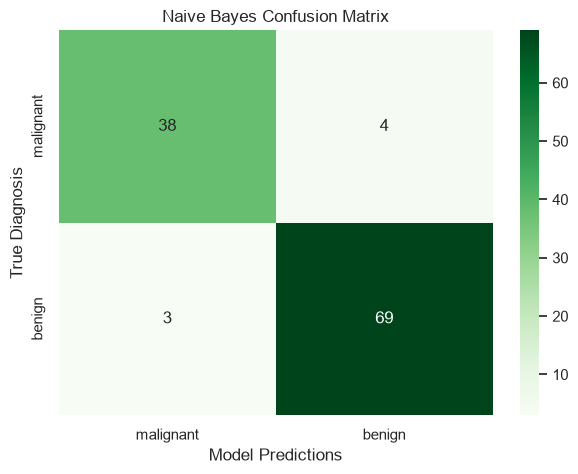

In [22]:
# Plot Confusion Matrix
conf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Greens',xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Model Predictions')
plt.ylabel('True Diagnosis')
plt.show()